Made By: **Adrian Earl Ng**
Section: **2ECE-C**

Initialization of libraries to be used

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**A. VISAYAS COMMUNICATION DATA FRAME**
Create a DataFrame named `VisComm` containing students whose Hometown is Visayas and whose Track is Communication. Retain only these columns, in the stated order: `Name`, `Gender`, `Math`, `Electronics`, `Average` 

Display the resulting DataFrame and its number of rows. Both filtering conditions must be applied to the source dataset before the columns are selected

In [19]:
board2 = pd.read_excel('board2.xlsx')
board2['Average'] = board2[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis = 1)
VisComm = board2.loc[(board2['Hometown']=='Visayas') & (board2['Track']=='Communication'), ['Name', 'Gender', 'Math', 'Electronics', 'Average']]
print ("Number of rows in DataFrame VisComm: ", VisComm.shape[0])
VisComm

Number of rows in DataFrame `VisComm`:  5


,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


**B. VISAYAS FEMALE DATAFRAME**
Create a second DataFrame named `VisFemale` containing students whose `Hometown` is *Visayas* and whose `Gender` is *Female*. Retain only: `Name`, `Track`, `GEAS`, `Electronics`, `Average`

Display `VisFemale`. Then display only the rows of `VisFemale` whose `Average` is at least **60**. Do not overwrite `VisFemale` when performing this second filter.

In [20]:
VisFemale = board2.loc[(board2['Hometown']=='Visayas') & (board2['Gender']=='Female'), ['Name', 'Track', 'GEAS', 'Electronics', 'Average']]
VisFemale

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


In [23]:
VisFemale.loc[(VisFemale['Average']>=60)]

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


**C. CATEGORY-AVERAGE VISUALIZATION**
Examine how the recorded `Average` differs across the three categorical features `Track`, `Gender`, and `Hometown`.
a. For each feature, compute the mean of `Average` for every category using **Pandas**.
b. Display the three summary tables.
c. Create one figure containing three bar charts: **mean Average by Track**, **by Gender**, and **by Hometown**.
d. Below the figure, write three concise statements identifying the category with the highest sample mean for each feature.

**Interpretation rule:** Describe the observed dataset only. A difference in group means does not, by itself, establish that a feature causes a higher board-exam score.

AttributeError: 'Figure' object has no attribute 'title'

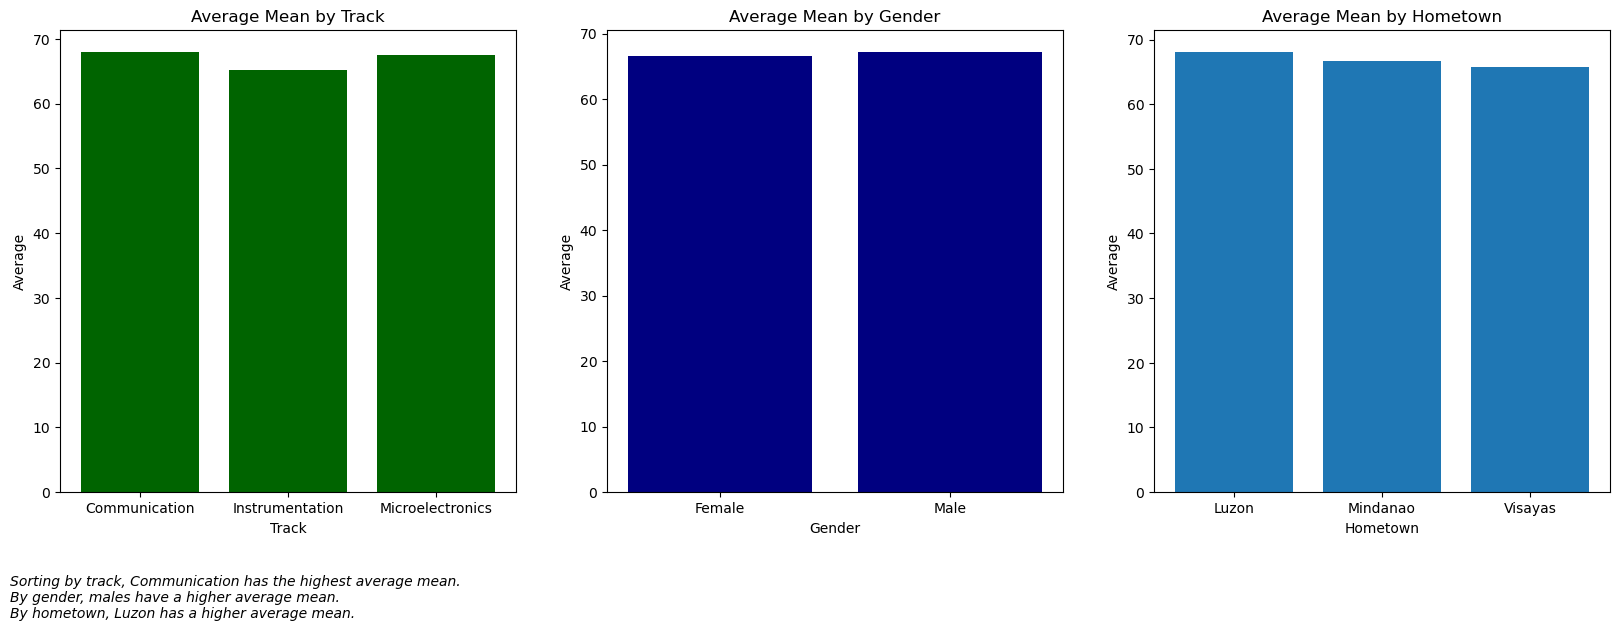

In [70]:
AveTr = board2.groupby('Track')['Average'].mean()
AveGe = board2.groupby('Gender')['Average'].mean()
AveHt = board2.groupby('Hometown')['Average'].mean()

ds = plt.figure(figsize=[20,6])
bar1, bar2, bar3 = ds.add_subplot(1, 3, 1), ds.add_subplot(1, 3, 2), ds.add_subplot(1, 3, 3)

bar1.bar(AveTr.index, AveTr.values, color='darkgreen')
bar1.set(title='Average Mean by Track', xlabel='Track', ylabel='Average')

bar2.bar(AveGe.index, AveGe.values, color='navy')
bar2.set(title='Average Mean by Gender', xlabel='Gender', ylabel='Average')

bar3.bar(AveHt.index, AveHt.values)
bar3.set(title='Average Mean by Hometown', xlabel='Hometown', ylabel='Average')

ds.text(0.1, -0.1, 'Sorting by track, Communication has the highest average mean.\nBy gender, males have a higher average mean.\nBy hometown, Luzon has a higher average mean.', style='oblique')